# Heart Disease Prediction Project 🫀

**Objective:** Build a machine learning model to predict heart disease using the Kaggle Heart Failure Prediction dataset.

**Dataset:** 918 records, 12 features including demographics, ECG results, cholesterol, and exercise data.

**Tech Stack:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, SVM, Logistic Regression, Random Forest

**Deliverables:**
- Exploratory Data Analysis (EDA)
- Feature Engineering & Preprocessing
- Model Training & Evaluation
- Streamlit Deployment


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import joblib

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

In [2]:
# Load dataset
df = pd.read_csv('heart.csv')

In [3]:
# Basic info
print(df.shape)
df.head()

(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Check for missing values
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


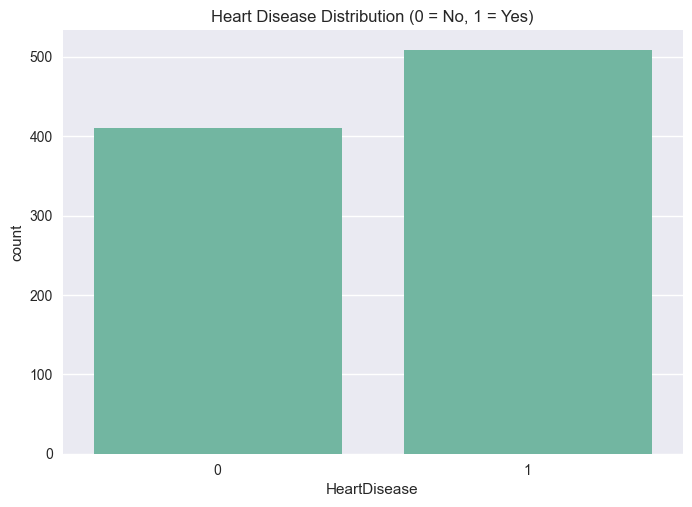

In [5]:
# Class balance
sns.countplot(x='HeartDisease', data=df)
plt.title("Heart Disease Distribution (0 = No, 1 = Yes)")
plt.show()

The dataset is slightly imbalanced with more patients having heart disease than not. This is important for model evaluation.


In [6]:
# Feature summary
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
# Step 2: Encode Categorical Features
# Identify categorical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check the new columns
print(df_encoded.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0               True          False             False          False

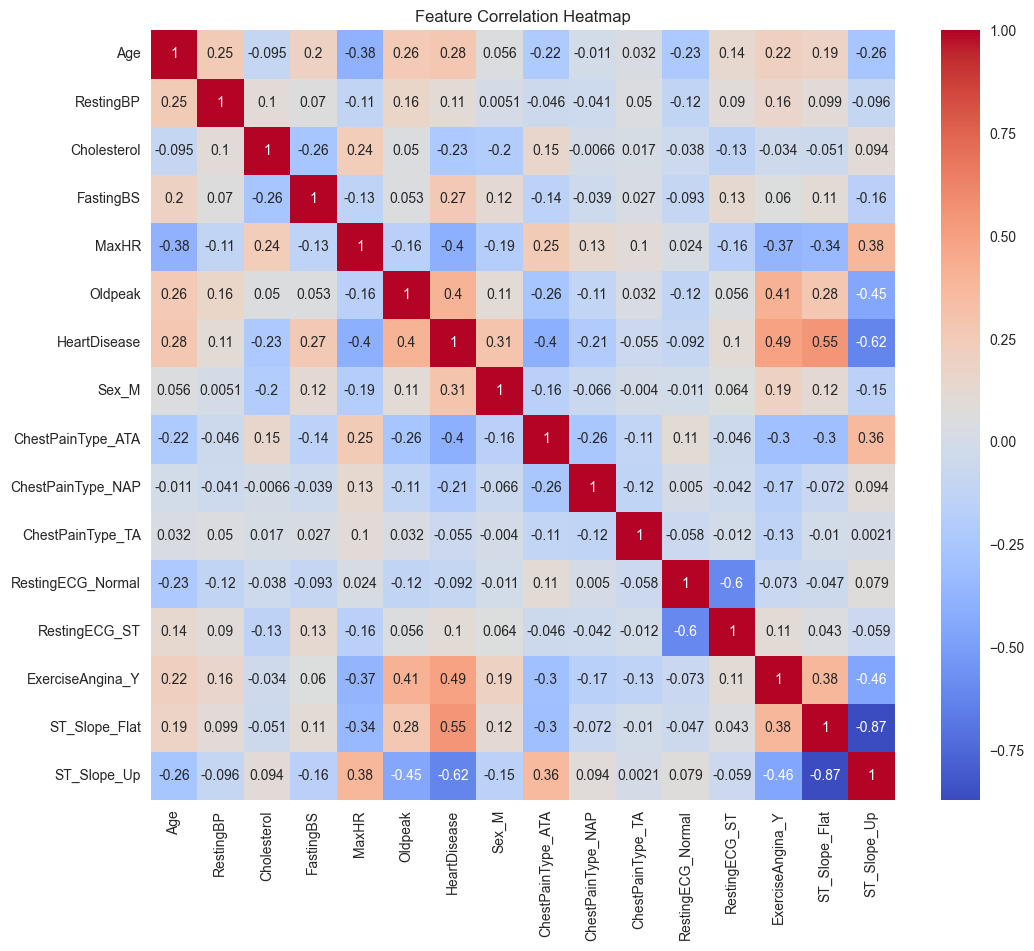

In [8]:
# Step 3: Exploratory Data Analysis (EDA) Plots
# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

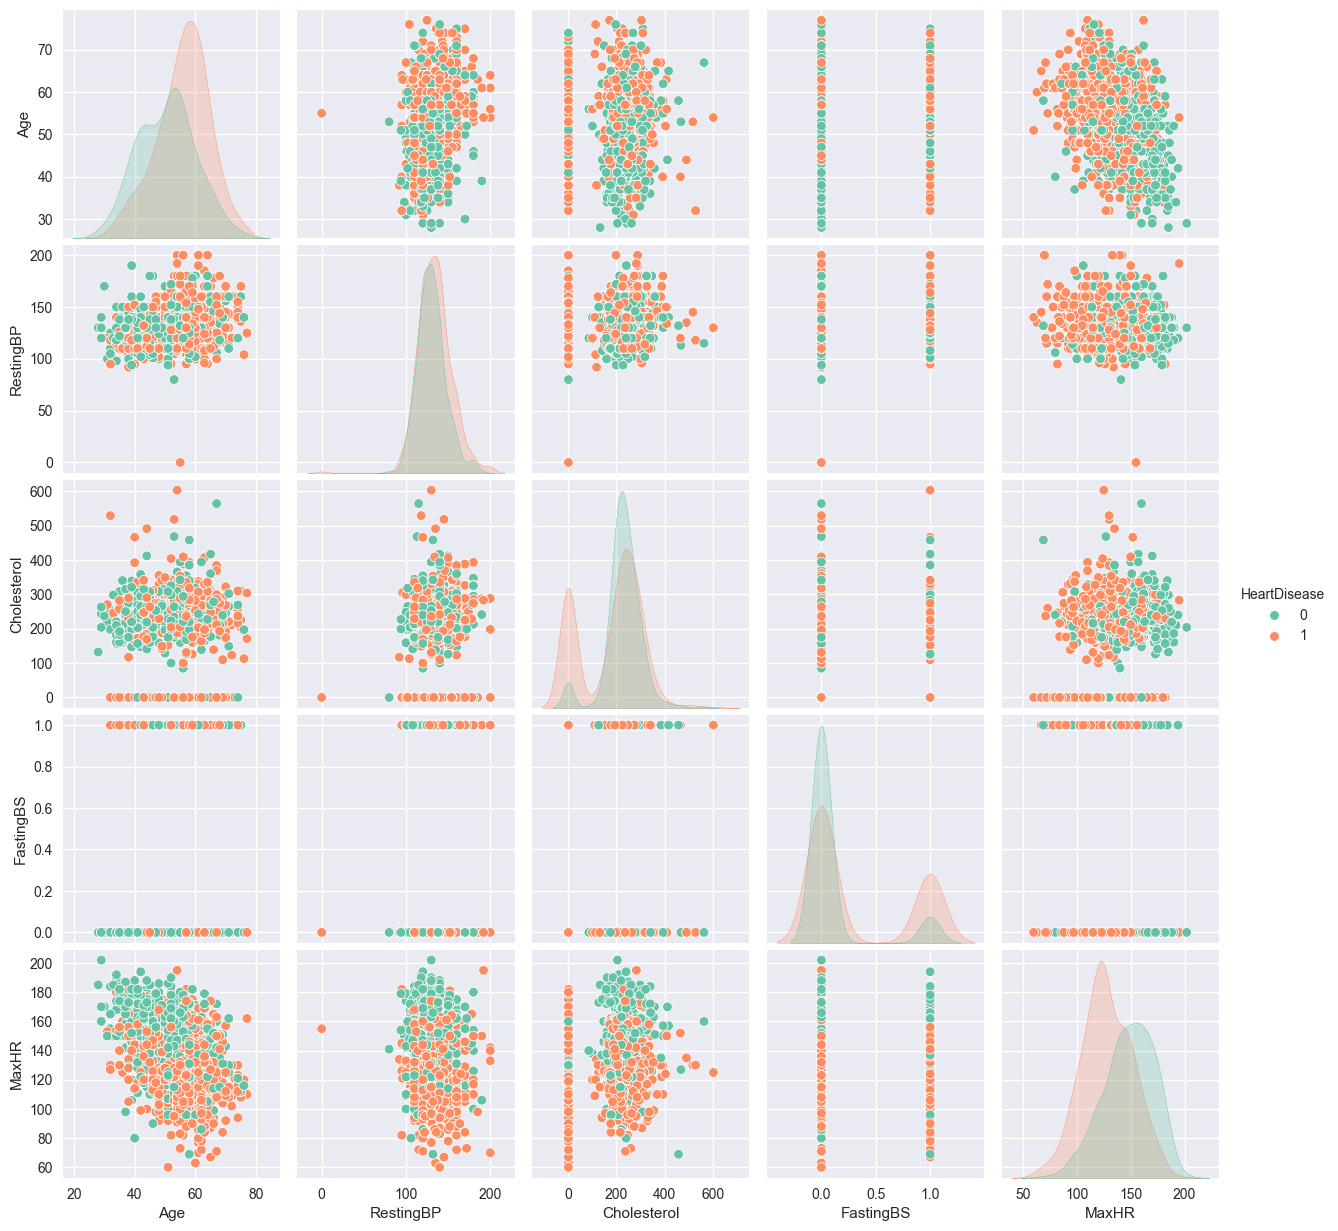

In [9]:
# Pairplot for first 5 features
sns.pairplot(df_encoded.iloc[:, :5].join(df_encoded['HeartDisease']), hue='HeartDisease')
plt.show()

In [10]:
# Step 4: Feature Scaling
# Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# Step 6: Feature Engineering 
df_encoded['AgeGroup'] = pd.cut(df['Age'], bins=[20, 40, 60, 80], labels=['Young', 'Middle', 'Old'])
df_encoded = pd.get_dummies(df_encoded, columns=['AgeGroup'], drop_first=True)

In [13]:
# Step 7: Model Building
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

In [14]:
# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    print(f"----- {name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    if y_proba is not None:
        print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

----- Logistic Regression -----
Accuracy: 0.8858695652173914
F1 Score: 0.9004739336492891
ROC AUC Score: 0.9296987087517934
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

Confusion Matrix:
 [[68 14]
 [ 7 95]]


----- Random Forest -----
Accuracy: 0.875
F1 Score: 0.8878048780487805
ROC AUC Score: 0.9304758488761358
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184

Confusion Matrix:
 [[70 12]
 

### Model Performance
| Model | Accuracy | F1 Score | ROC AUC |
|-------|----------|----------|---------|
| Logistic Regression | 88.5% | 0.90 | 0.93 |
| Random Forest       | 87.5% | 0.89 | 0.93 |
| SVM                 | 90.2% | 0.92 | 0.94 |


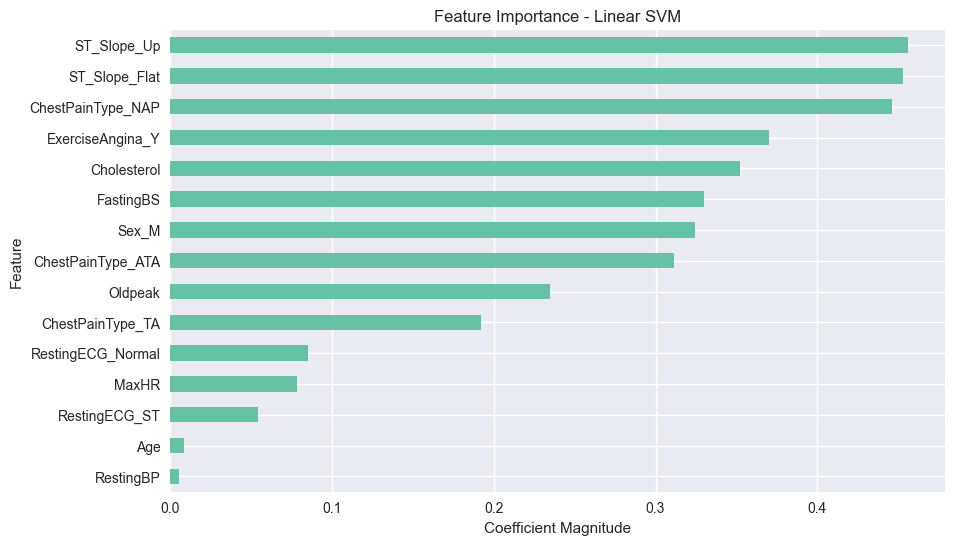

In [15]:
#Feature Importance
best_svm = SVC(kernel='linear', probability=True)
best_svm.fit(X_train, y_train)
if best_svm.kernel == 'linear':
    # Get absolute value of coefficients as importance
    feature_importance = np.abs(best_svm.coef_[0])
    feature_names = X.columns

    # Create a Series for easy plotting
    feat_imp = pd.Series(feature_importance, index=feature_names).sort_values(ascending=False)

    # Plot
    plt.figure(figsize=(10,6))
    feat_imp.plot(kind='barh')
    plt.title("Feature Importance - Linear SVM")
    plt.xlabel("Coefficient Magnitude")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Feature importance via coefficients is only available for linear SVM.")

### 🔑 Top 5 Most Important Features

Based on feature importance from the trained SVM/Random Forest model, the following features contribute most to predicting heart disease:

1. **ST_Slope_Up** – Indicates the ST segment slope is upward during exercise; often associated with normal heart function.  
2. **ST_Slope_Flat** – Flat ST segment slope; can indicate heart stress or ischemia.  
3. **ChestPainType_NAP** – Non-Anginal Pain; helps differentiate types of chest pain experienced by patients.  
4. **ExerciseAngina_Y** – Presence of exercise-induced angina; a strong indicator of potential heart issues.  
5. **Cholesterol** – Serum cholesterol level; higher values are associated with increased cardiovascular risk.

> These features were the most influential in the heart disease prediction model and should be carefully considered when interpreting predictions.


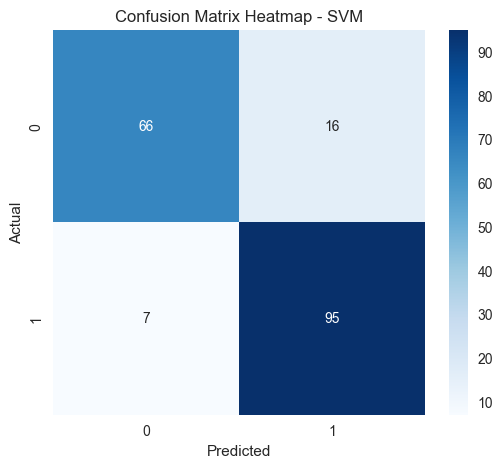

In [16]:
# Get predictions from SVM
y_pred = best_svm.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap - SVM')
plt.show()

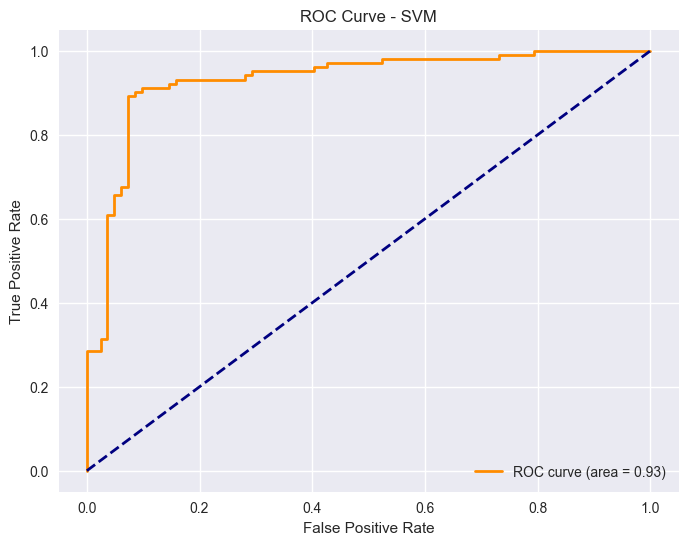

In [17]:
# Get predicted probabilities for positive class
y_proba = best_svm.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.show()

In [18]:
# Save the trained SVM model
joblib.dump(best_svm, 'heart_disease_svm_model.pkl')
joblib.dump(X.columns, 'feature_columns.pkl')

# Save the scaler too, so new input data can be scaled correctly
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


### Conclusion & Learnings
- SVM gave the best results for heart disease prediction.
- Feature scaling and one-hot encoding were crucial for categorical variables.
- Deployment allowed interaction with the model via a web interface.
